In [4]:
import sys
import os
import time

from SelfCal import PipelineWrapper
from SelfCal.SPHERExUtility import make_fiducial_chunk_map, make_fiducial_chunk_mask, \
load_calibration, make_spherex_offset_map, compute_offsets_guess
from SelfCal.SPHERExAppendWav import wav_coadd

from astropy.io import fits
import numpy as np
import glob
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 200
# Import LogNorm
from tqdm import tqdm
import gc
from functools import partial


In [5]:
DETECTOR = 1
OVERSAMPLE_FACTOR = 2
NUM_SUBCHANNELS = 10
NUM_CHANNELS = 17
NUM_VERTICAL_BANDS = 3
FILE_SUFFIX = f'_vertical{NUM_VERTICAL_BANDS}bands'
FILE_PREFIX = f''

config = {}
config['output_dir'] = '/mnt/md124/thomasli/selfcal/outputs/'
config['run_name'] = f'nep_det{DETECTOR}_6p2arcsec'
config['resolution_arcsec'] = 6.2


In [8]:
DETECTOR = 4
OVERSAMPLE_FACTOR = 2
NUM_SUBCHANNELS = 10
NUM_CHANNELS = 34
FILE_SUFFIX = ''
FILE_PREFIX = f''

config = {}
config['output_dir'] = '/mnt/md124/thomasli/selfcal/outputs/'
config['run_name'] = f'nep_det{DETECTOR}_3p1arcsec'
config['resolution_arcsec'] = 3.1


In [9]:
det_BC, det_BW = load_calibration(band=DETECTOR, calibration_dir='/home/thomasli/spherex/SPHEREx_Spectral_Calibration')
chunk_map, lvf_params = make_fiducial_chunk_map(DETECTOR, det_BC, num_subchannels=NUM_SUBCHANNELS, num_channels=NUM_CHANNELS, 
                                                oversample_factor=OVERSAMPLE_FACTOR)
det_chunk_map, _ = make_fiducial_chunk_map(DETECTOR, det_BC, num_subchannels=NUM_SUBCHANNELS, num_channels=NUM_CHANNELS, 
                                           oversample_factor=1, lvf_params=lvf_params)

Fitting LVF parameters...


 16%|██████████████████▏                                                                                                  | 53/341 [00:06<00:34,  8.37it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 341/341 [00:40<00:00,  8.42it/s]


Making chunk map...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 341/341 [00:40<00:00,  8.39it/s]


Making chunk map...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 341/341 [00:15<00:00, 22.04it/s]


In [10]:
chunk_valid_mask = make_fiducial_chunk_mask([23, 24], num_subchannels=NUM_SUBCHANNELS, num_channels=NUM_CHANNELS)

In [20]:
chunk_valid_mask.nonzero()

(array([225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235]),)

In [35]:
chunk_valid_mask = np.zeros(342)
chunk_valid_mask[249:260] = 1

In [37]:
np.min(det_BC[chunk_valid_mask[det_chunk_map].astype(bool)])

np.float64(3.373567863050042)

In [17]:
det_BC, det_BW = load_calibration(band=DETECTOR, calibration_dir='/home/thomasli/spherex/SPHEREx_Spectral_Calibration')
grid_subchannel_map, lvf_params = make_fiducial_chunk_map(DETECTOR, det_BC, num_subchannels=NUM_SUBCHANNELS, num_channels=NUM_CHANNELS, 
                                                oversample_factor=OVERSAMPLE_FACTOR)
det_subchannel_map, _ = make_fiducial_chunk_map(DETECTOR, det_BC, num_subchannels=NUM_SUBCHANNELS, num_channels=NUM_CHANNELS, 
                                           oversample_factor=1, lvf_params=lvf_params)

Fitting LVF parameters...


 32%|████████████████████████████████████▉                                                                                | 54/171 [00:00<00:01, 74.67it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 171/171 [00:02<00:00, 74.39it/s]


Making chunk map...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 171/171 [00:05<00:00, 33.19it/s]


Making chunk map...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 171/171 [00:01<00:00, 140.24it/s]


In [18]:
grid_vertchunk_map = np.zeros_like(grid_subchannel_map)
det_vertchunk_map = np.zeros_like(det_subchannel_map)

for band in range(NUM_VERTICAL_BANDS):
    grid_width = grid_vertchunk_map.shape[1] // NUM_VERTICAL_BANDS
    grid_vertchunk_map[:, band*grid_width:(band+1)*grid_width] = band
    det_width = det_vertchunk_map.shape[1] // NUM_VERTICAL_BANDS
    det_vertchunk_map[:, band*det_width:(band+1)*det_width] = band

grid_chunk_map = grid_subchannel_map*NUM_VERTICAL_BANDS + grid_vertchunk_map
det_chunk_map = det_subchannel_map*NUM_VERTICAL_BANDS + det_vertchunk_map

In [19]:
ch = [7]

subchannel_valid_mask = make_fiducial_chunk_mask(ch, num_subchannels=NUM_SUBCHANNELS, num_channels=NUM_CHANNELS, padding=1)

chunk_valid_mask = np.zeros(len(subchannel_valid_mask)*NUM_VERTICAL_BANDS, dtype=subchannel_valid_mask.dtype)
for band in range(NUM_VERTICAL_BANDS):
    chunk_valid_mask[band::NUM_VERTICAL_BANDS] = subchannel_valid_mask

grid_valid_mask = chunk_valid_mask[grid_chunk_map]
det_valid_mask = chunk_valid_mask[det_chunk_map]

In [ ]:
cc = PipelineWrapper.Calibrator(config)
cc.setup_lsqr(
    apply_mask=True, 
    apply_weight=True, 
    chunk_map=grid_chunk_map, 
    det_valid_mask=grid_valid_mask, 
    max_workers=50, 
    outlier_thresh=10.0,
    ignore_list=[],
    oversample_factor=OVERSAMPLE_FACTOR,
    batch_size=30
    )

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4412/4412 [00:00<00:00, 532295.97it/s]


Loading reference frame from: /mnt/md124/thomasli/selfcal/outputs/nep_det1_6p2arcsec/ref.fits
Processing 4412 items in 148 batches (Batch Size: 30)...


Building A, b matrix:  45%|███████████████████████████████████████████                                                    | 67/148 [04:41<05:39,  4.20s/it]


Process ForkProcess-143:
Process ForkProcess-167:
Process ForkProcess-165:
Process ForkProcess-172:
Process ForkProcess-175:
Process ForkProcess-161:
Process ForkProcess-171:
Process ForkProcess-179:
Process ForkProcess-177:
Process ForkProcess-180:
Process ForkProcess-178:
Process ForkProcess-164:
Process ForkProcess-134:
Process ForkProcess-139:
Process ForkProcess-169:
Process ForkProcess-131:
Process ForkProcess-144:
Process ForkProcess-140:
Process ForkProcess-176:
Process ForkProcess-153:
Process ForkProcess-141:
Process ForkProcess-154:
Process ForkProcess-152:
Process ForkProcess-159:
Process ForkProcess-133:
Process ForkProcess-173:
Process ForkProcess-147:
Process ForkProcess-158:
Process ForkProcess-170:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Process ForkProcess-132:
Traceback (most recent call last):
Process ForkProcess-136:
Process ForkProcess-174:
Process ForkProcess-146:


KeyboardInterrupt: 

Traceback (most recent call last):
Process ForkProcess-151:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/thomasli/anaconda3/envs/general/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/home/thomasli/anaconda3/envs/general/lib/python3.13/

In [8]:
(cc.A.shape[1]-cc.ref_shape[0]*cc.ref_shape[1])/len(cc.reproj_list)

2580.0

In [ ]:
print('Memory usage:')
total_bytes = cc.A.data.nbytes + cc.A.coords[0].nbytes + cc.A.coords[1].nbytes
print(total_bytes / (1024**3), 'GB')

Memory usage:
13.40981213003397 GB


In [ ]:
cc.apply_lsqr(x0=None, atol=1e-06, btol=1e-06, damp=1e-3, iter_lim=200)

Solving least squares for 92582252 unknowns with 586661389 equations.
 
LSQR            Least-squares solution of  Ax = b
The matrix A has 586661389 rows and 92582252 columns
damp = 1.00000000000000e-03   calc_var =        0
atol = 1.00e-06                 conlim = 1.00e+08
btol = 1.00e-06               iter_lim =      200


 
   Itn      x[0]       r1norm     r2norm   Compatible    LS      Norm A   Cond A
     0  0.00000e+00   2.422e+04  2.422e+04    1.0e+00  8.5e-03
     1  0.00000e+00   5.946e+03  5.946e+03    2.5e-01  8.3e-01   2.1e+02  1.0e+00
     2  0.00000e+00   3.023e+03  3.023e+03    1.2e-01  9.8e-01   3.0e+02  2.0e+00
     3  0.00000e+00   2.755e+03  2.755e+03    1.1e-01  1.7e-01   7.9e+02  5.6e+00
     4  0.00000e+00   2.352e+03  2.352e+03    9.7e-02  2.1e-01   8.8e+02  7.4e+00
     5  0.00000e+00   2.116e+03  2.116e+03    8.7e-02  7.4e-02   1.0e+03  9.5e+00
     6  0.00000e+00   2.042e+03  2.042e+03    8.4e-02  8.6e-02   1.1e+03  1.1e+01
     7  0.00000e+00   1.953e+03  1.953e+03    8.1e-02  8.1e-02   1.2e+03  1.3e+01
     8  0.00000e+00   1.932e+03  1.932e+03    8.0e-02  3.6e-02   1.4e+03  1.6e+01
     9  0.00000e+00   1.889e+03  1.889e+03    7.8e-02  3.9e-02   1.4e+03  1.9e+01
    10  0.00000e+00   1.851e+03  1.851e+03    7.6e-02  2.3e-02   1.5e+03  2.2e+01
   190  0.00000e+00   1.052e+03  1

In [ ]:
cal_path = cc.save_calibration(cal_file=f'cal{FILE_PREFIX}_D{DETECTOR}_Ch{"-".join(map(str, ch))}{FILE_SUFFIX}.h5')

Calibration saved to /mnt/md124/thomasli/selfcal/outputs/nep_det1_6p2arcsec/calibration/cal_D1_Ch7_vertical15bands.h5


In [13]:
cc.O.shape

(4412, 2580)

In [14]:
chunk_cube = np.array([det_chunk_map == i for i in tqdm(np.arange(np.max(det_chunk_map)+1))])
mean_offset_map = np.einsum('i,ijk->jk', cc.O.mean(axis=0), chunk_cube)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2580/2580 [00:09<00:00, 273.92it/s]


In [15]:
chunk_cube.shape

(2580, 2040, 2040)

In [38]:
single_offset_map = np.einsum('i,ijk->jk', cc.O[100], chunk_cube)

In [152]:
from SelfCal.MapHelper import bin2d_cv

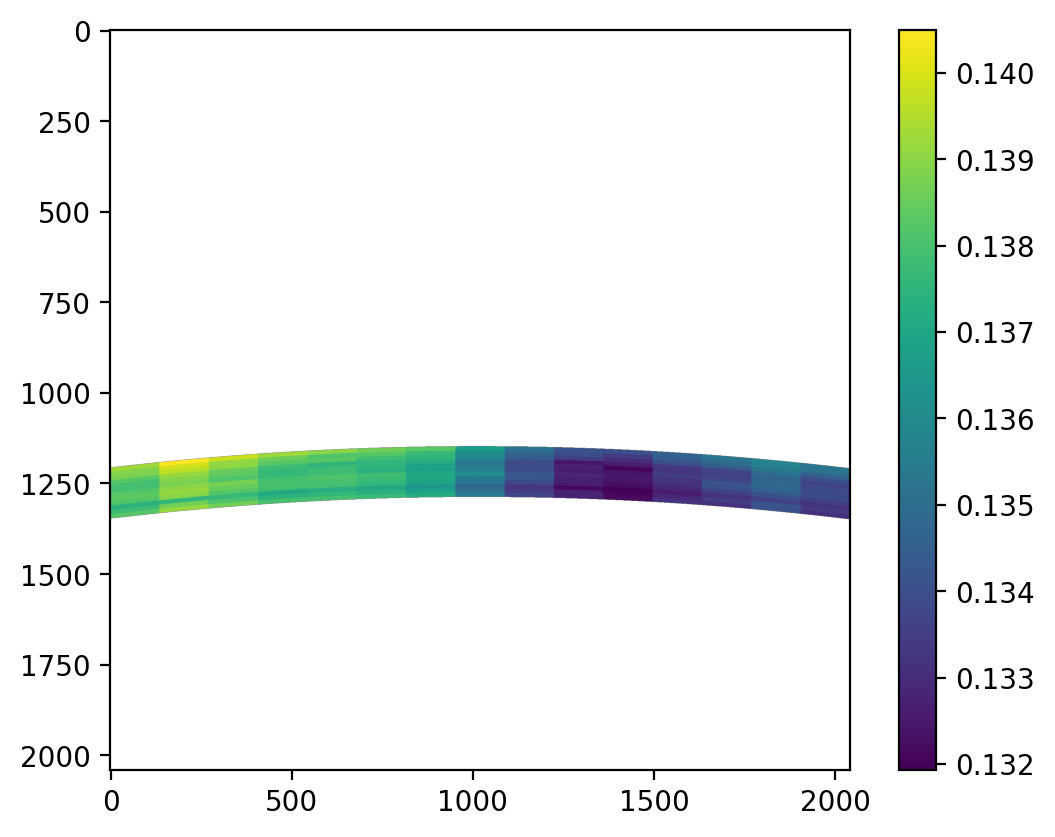

In [18]:
plt.imshow(np.where(det_valid_mask, mean_offset_map, np.nan))
# plt.ylim(3000, 3500)
plt.colorbar()

In [45]:
chunk_valid_mask

array([0., 0., 0., ..., 0., 0., 0.], shape=(2580,))

In [48]:
R = lvf_params['R']
xc, yc = lvf_params['xc'], lvf_params['yc']

edge_valid_mask = subchannel_valid_mask[1:].astype(bool) | subchannel_valid_mask[:-1].astype(bool)
edge_R = R[edge_valid_mask]

In [54]:
edge_x = np.linspace(0, 2040, NUM_VERTICAL_BANDS+1)

In [57]:
def mean_preserving_spline_2d(x_edges, y_edges, z_means, kx=3, ky=3):
    """
    Generates a mean-preserving spline function f(x, y) based on 2D grid edges
    and the average value z_mean in each rectangular cell.

    The function f(x, y) is constructed as the mixed partial derivative of a 
    bicubic spline F(x, y), where F(x, y) is the double integral of f(x, y).

    Parameters
    ----------
    x_edges : array_like, shape (N+1,)
        The edges of the bins along the x-axis.
    y_edges : array_like, shape (M+1,)
        The edges of the bins along the y-axis.
    z_means : array_like, shape (N, M)
        The mean value of the function within each rectangular bin.
    kx, ky : int, optional
        The degrees of the spline in x and y directions. Default is 3 (bicubic).
        
    Returns
    -------
    f_spline : callable
        A function f(x, y, grid=False) that evaluates the interpolated density.
        - If grid=True, evaluates on the grid spanned by x and y vectors.
        - If grid=False, evaluates at coordinates (x, y).
    """
    x_edges = np.asarray(x_edges, dtype=float)
    y_edges = np.asarray(y_edges, dtype=float)
    z_means = np.asarray(z_means, dtype=float)

    # 1. Validation
    if x_edges.shape[0] != z_means.shape[0] + 1:
        raise ValueError("len(x_edges) must be len(z_means) + 1 (rows)")
    if y_edges.shape[0] != z_means.shape[1] + 1:
        raise ValueError("len(y_edges) must be z_means.shape[1] + 1 (cols)")

    # 2. Compute Interval Areas (Volumes)
    # dx: (N,) -> column vector (N, 1)
    # dy: (M,) -> row vector (1, M)
    dx = np.diff(x_edges)
    dy = np.diff(y_edges)
    
    # Calculate volume of each cell: z_mean * dx * dy
    # Broadcasting: (N, 1) * (1, M) * (N, M)
    cell_volumes = z_means * dx[:, None] * dy[None, :]

    # 3. Compute Cumulative Integrals (2D Cumulative Sum)
    # The integral at (x0, y0) is 0.
    # The integral at (xi, yj) is sum of volumes in rect defined by [0:i, 0:j]
    integral_grid = np.zeros((len(x_edges), len(y_edges)))
    
    # cumsum over x (axis 0), then over y (axis 1)
    cumulative_volumes = np.cumsum(np.cumsum(cell_volumes, axis=0), axis=1)
    
    # Fill the integral grid (row 0 and col 0 remain 0s)
    integral_grid[1:, 1:] = cumulative_volumes

    # 4. Interpolate the Integral Surface F(x, y)
    # RectBivariateSpline creates a smooth surface over the regular grid
    F_spline = RectBivariateSpline(x_edges, y_edges, integral_grid, kx=kx, ky=ky)

    # 5. Define the Density Function
    # f(x, y) = d^2 F / dx dy
    # RectBivariateSpline allows calculating partial derivatives directly.
    
    def f_spline(x, y, grid=False):
        """
        Evaluate the mean-preserving spline.
        grid=True: x and y are vectors defining a grid.
        grid=False: x and y are coordinates of points.
        """
        # Calculate mixed partial derivative (dx=1, dy=1)
        return F_spline(x, y, dx=1, dy=1, grid=grid)

    return f_spline

In [ ]:
valid_offset = 

In [ ]:

mm = PipelineWrapper.Mosaicker(config)
mm.load_calibration(cal_path='/mnt/md124/thomasli/selfcal/outputs/nep_det1_6p2arcsec/calibration/cal_D1_Ch7_vertical3bands.h5')
# partial_make_offset_map = partial(make_spherex_offset_map, chunk_valid_mask=chunk_valid_mask, lvf_params=lvf_params)
sc_sigma = 1.0
maps = mm.make_mosaic(
    apply_mask=True, 
    apply_weight=False, 
    chunk_map=grid_chunk_map, 
    det_valid_mask=grid_valid_mask, 
    max_workers=20,
    make_std_map=True, 
    apply_sigma_clipping=True,  
    sigma=sc_sigma,
    ignore_list=[21],
    oversample_factor=OVERSAMPLE_FACTOR,
    det_offset_func=None,#partial_make_offset_map,
    cache_batch_size=20,
    coadd_batch_size=100,
    cache_dir='/home/thomasli/spherex/selfcal/cache',
    cache_intermediate=True,
    det_aux=None
)

    # wav_mean, wav_std = wav_coadd(det_BC, det_BW, mean_map=maps['mean_map']['data'], std_map=maps['std_map']['data'], 
    #                               reproj_list=mm.reproj_list, cache_list=mm.cached_list, ref_shape=maps['mean_map']['data'].shape, 
    #                               sigma=sc_sigma, batch_size=40, max_workers=40)    

    # wav_mean_maps = {'data': wav_mean, 'unit': 'um'}
    # wav_std_maps = {'data': wav_std, 'unit': 'um'}
    # mm.append_maps({'wav_mean_map': wav_mean_maps, 'wav_std_map': wav_std_maps})

mm.save_mosaic(mos_file=f'mosaic{FILE_PREFIX}_D{DETECTOR}_Ch{"-".join(map(str, ch))}{FILE_SUFFIX}.fits', overwrite=True)

    # # Clear memory
    # del mm, maps
    # gc.collect()
    # t1 = time.time()
    # print(f"Finished channel {ch} for detector {DETECTOR} in {t1 - t0:.2f} seconds")


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4412/4412 [00:00<00:00, 1684441.04it/s]


Loading reference frame from: /mnt/md124/thomasli/selfcal/outputs/nep_det1_6p2arcsec/ref.fits
Calibration loaded from /mnt/md124/thomasli/selfcal/outputs/nep_det1_6p2arcsec/calibration/cal_D1_Ch7_vertical15bands.h5
Caching intermediate computations...
Processing 4412 files in 221 batches...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 221/221 [04:57<00:00,  1.35s/it]

Cache computation finished in 298.24 seconds.
Computing mean map...
Processing 4412 files in 45 batches...



100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [01:33<00:00,  2.07s/it]


...

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [01:35<00:00,  2.11s/it]


Std map computation finished in 96.71 seconds.
Computing sigma-clipped mean map...
Processing 4412 files in 45 batches...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [01:37<00:00,  2.17s/it]


Sigma-clipped mean map computation finished in 99.60 seconds.
Mosaic saved to /mnt/md124/thomasli/selfcal/outputs/nep_det1_6p2arcsec/mosaic/mosaic_D1_Ch7_vertical15bands.fits


'/mnt/md124/thomasli/selfcal/outputs/nep_det1_6p2arcsec/mosaic/mosaic_D1_Ch7_vertical15bands.fits'

In [ ]:
mosaic = mm.maps['mean_map']['data']

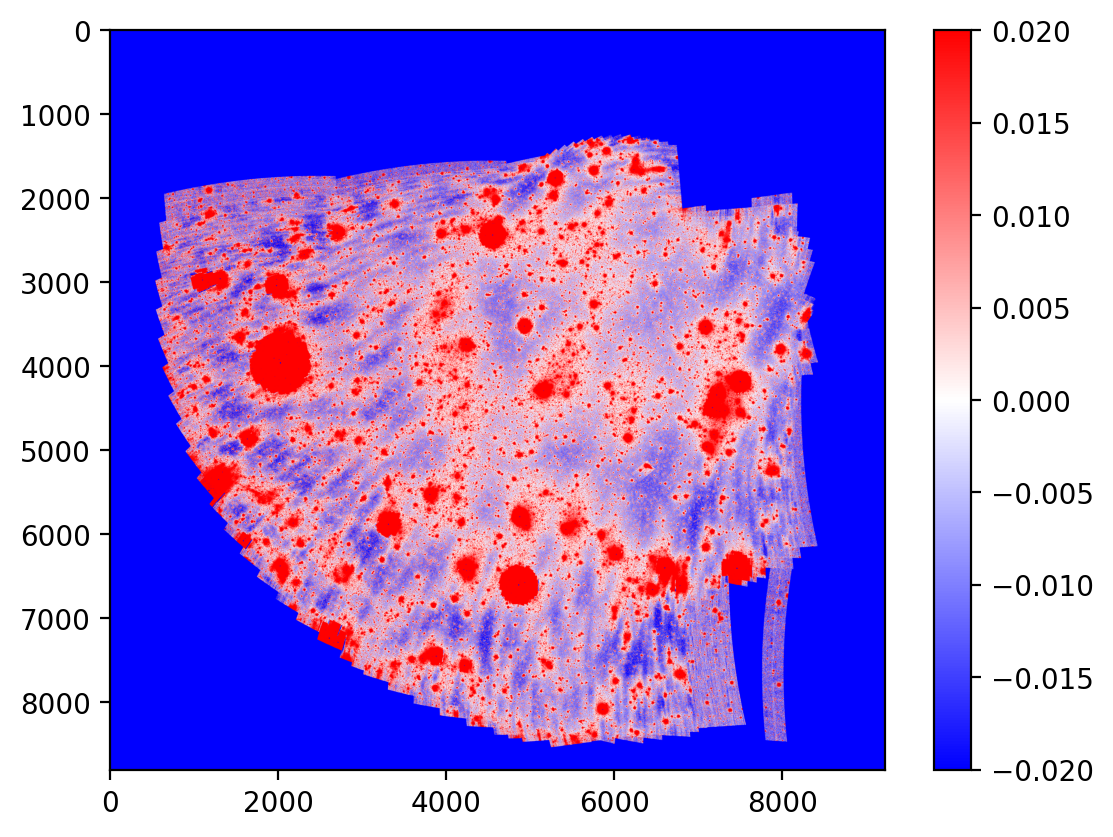

In [ ]:
plt.imshow(mosaic-np.nanmedian(mosaic[np.nonzero(mosaic)]), vmin=-0.02, vmax=0.02, cmap='bwr')
plt.colorbar()

In [111]:
len(np.unique(chunk_map1))